In [18]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nbt import nbt
import base64
import gzip
import io
import re
from tqdm import tqdm
from collections import defaultdict
from tqdm import tqdm
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Load the mysql database into memory

In [5]:
# 1. Manually find the .env file relative to this notebook
# '..' goes up to src, the second '..' goes up to the root
env_path = Path('../../.env')
load_dotenv(dotenv_path=env_path)

# 2. Now os.getenv will work
USER = os.getenv("MYSQL_USER")
PASSWORD = os.getenv("MYSQL_PASSWORD")
DATABASE = os.getenv("MYSQL_DATABASE")
HOST = "localhost"
HOST = "192.168.86.4"
PORT = "3306"

# 3. Create the engine and load
engine = create_engine(f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")

df = pd.read_sql("SELECT * FROM auctions", engine)
print(df)

print(f"Success! Loaded {len(df)} rows.")

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
3       0000bc576d704962a0dfc9d93a3bf12e  ca1b079bc12c48229fd4ad227994e5c4   
4       0000e8c0e7fd4ecea683bb9b7f281863  9144688d5a9d4271b97ffbd49c6fe56d   
...                                  ...                               ...   
320873  fffed6d0c1224f27be3bec5b6a89ac01  ef6719f1e81948979b6fe965d33627c4   
320874  fffee76250134299a072e2a743146fec  73e45fa19fce4beab3da3a35bfb6e1fa   
320875  fffef5db947d43e4ae1ee57a67c8ab69  032e4896d71f42a2b96a2b635b27dbb4   
320876  ffff35895c8e4f2d9557fcfd796c0862  1d8badf4062c437a895a4b83c1a4d4fe   
320877  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   

                              buyer_uuid  final_price  bin  \
0

In [15]:
def print_all_tags(tag, indent=0):
    """
    Recursively prints all NBT tags and their values.
    """
    prefix = "  " * indent
    
    # If it's a Compound tag (like a folder/dictionary)
    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            print(f"{prefix}{key}:")
            print_all_tags(value, indent + 1)
            
    # If it's a List tag
    elif isinstance(tag, nbt.TAG_List):
        print(f"{prefix}[List of {len(tag)} items]")
        for i, item in enumerate(tag):
            print(f"{prefix}  Index {i}:")
            print_all_tags(item, indent + 2)
            
    # If it's a standard Value tag (String, Int, Byte, etc.)
    else:
        # Clean formatting codes if the value is a string
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        print(f"{prefix}{val}")


def decode_nbt(raw_base64):
    try:
        # 1. Decode Base64
        decoded_data = base64.b64decode(raw_base64)
        
        # 2. Decompress GZip
        uncompressed_data = gzip.decompress(decoded_data)
        
        # 3. Parse NBT
        buffer = io.BytesIO(uncompressed_data)
        nbt_data = nbt.NBTFile(buffer=buffer)
        
        # 4. Navigate to the first item in the list
        # Skyblock/Minecraft auction data usually wraps items in an 'i' list
        items_list = nbt_data["i"]
        return items_list
            
    except Exception as e:
        #print(f"Failed to decode NBT: {e}")
        pass

def decode_and_print_all(raw_base64):
    try:
        items_list = decode_nbt(raw_base64)
        
        for index, item in enumerate(items_list):
            print(f"--- Item #{index} ---")
            print_all_tags(item)
            print("-" * 20)
            
    except Exception as e:
        print(f"Failed to decode NBT: {e}")

## Processing

In [7]:
# Get the raw counts
bin_counts = df['bin'].value_counts()

print("Distribution of Auction Types:")
print(f"BIN (1): {bin_counts.get(1, 0)}")
print(f"Auction (0): {bin_counts.get(0, 0)}")

# Pro-tip: For ML, you often want the percentage/proportion
print("\nProportions:")
print(df['bin'].value_counts(normalize=True))

Distribution of Auction Types:
BIN (1): 315672
Auction (0): 5206

Proportions:
bin
1    0.983776
0    0.016224
Name: proportion, dtype: float64


Seeing as how under 2% of collected auctions were not BIN (Buy It Now), but regular bidding auctions, I have decided to remove these from the training data because in regular auctions, bidding wars occur, where people bid with emotion, not logic, and tend to overpay.


In [8]:
df = df[df['bin'] == 1]
print(df)

                            auction_uuid                       seller_uuid  \
0       00001b5924f7416cbfc07aea2bc1fe97  a2c1748fc4924d13a9a7f485bbddf2b2   
1       00007a777db64d88ba510f8a36a7fc86  c180cd6ee2d54867939a222330873214   
2       0000a9452010475c8eeb48cfcd1088cc  2866ef326f4f47d59b85eda1c501971d   
3       0000bc576d704962a0dfc9d93a3bf12e  ca1b079bc12c48229fd4ad227994e5c4   
4       0000e8c0e7fd4ecea683bb9b7f281863  9144688d5a9d4271b97ffbd49c6fe56d   
...                                  ...                               ...   
320873  fffed6d0c1224f27be3bec5b6a89ac01  ef6719f1e81948979b6fe965d33627c4   
320874  fffee76250134299a072e2a743146fec  73e45fa19fce4beab3da3a35bfb6e1fa   
320875  fffef5db947d43e4ae1ee57a67c8ab69  032e4896d71f42a2b96a2b635b27dbb4   
320876  ffff35895c8e4f2d9557fcfd796c0862  1d8badf4062c437a895a4b83c1a4d4fe   
320877  ffffb3be64234313a3655b5734ccd339  21fcfb8104ab4016b4d2fb21a2314b30   

                              buyer_uuid  final_price  bin  \
0

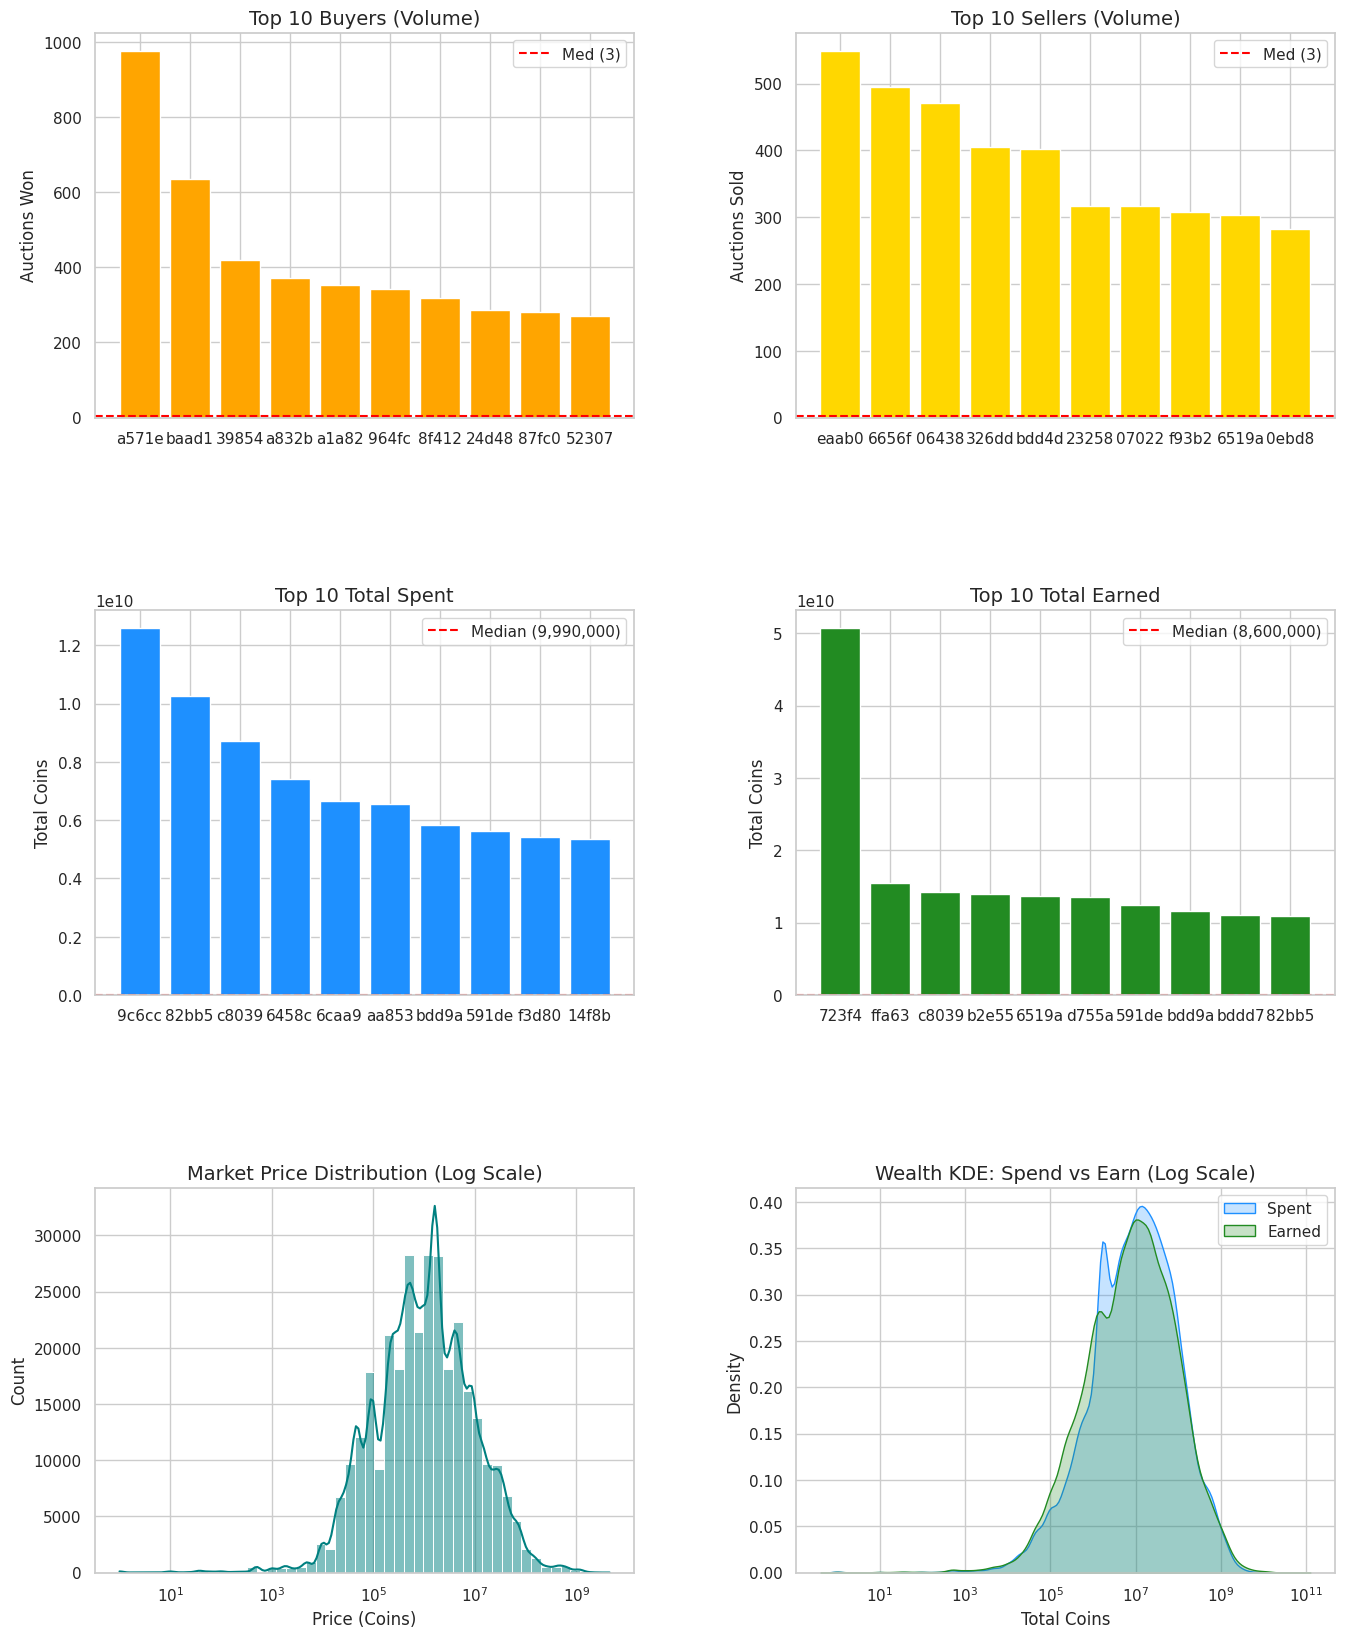

In [9]:
# --- 1. Setup Style & Canvas ---
sns.set_theme(style="whitegrid")
# Using a 3x2 grid to fit all 6 visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# --- ROW 1: VOLUME (TRANSACTION COUNTS) ---

# 1. Top 10 Buyers (Last 5 Chars)
buyer_counts = df['buyer_uuid'].value_counts().head(10)
short_buyer_ids = [str(x)[-5:] for x in buyer_counts.index]
axes[0, 0].bar(short_buyer_ids, buyer_counts.values, color='orange')
median_purchases = df['buyer_uuid'].value_counts().median()
axes[0, 0].axhline(y=median_purchases, color='red', linestyle='--', label=f'Med ({median_purchases:,.0f})')
axes[0, 0].set_title('Top 10 Buyers (Volume)', fontsize=14)
axes[0, 0].set_ylabel('Auctions Won')
axes[0, 0].legend()

# 2. Top 10 Sellers (Last 5 Chars)
seller_counts = df['seller_uuid'].value_counts().head(10)
short_seller_ids = [str(x)[-5:] for x in seller_counts.index]
axes[0, 1].bar(short_seller_ids, seller_counts.values, color='gold')
median_sales = df['seller_uuid'].value_counts().median()
axes[0, 1].axhline(y=median_sales, color='red', linestyle='--', label=f'Med ({median_sales:,.0f})')
axes[0, 1].set_title('Top 10 Sellers (Volume)', fontsize=14)
axes[0, 1].set_ylabel('Auctions Sold')
axes[0, 1].legend()

# --- ROW 2: VALUE (COIN FLOW) ---

# 3. Top 10 Spenders (Last 5 Chars)
spent_per_player = df.groupby('buyer_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_spender_ids = [str(x)[-5:] for x in spent_per_player.index]
axes[1, 0].bar(short_spender_ids, spent_per_player.values, color='dodgerblue')
median_spent = df.groupby('buyer_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 0].axhline(y=median_spent, color='red', linestyle='--', label=f'Median ({median_spent:,.0f})')
axes[1, 0].set_title('Top 10 Total Spent', fontsize=14)
axes[1, 0].set_ylabel('Total Coins')
axes[1, 0].legend()

# 4. Top 10 Earners (Last 5 Chars)
earned_per_player = df.groupby('seller_uuid')['final_price'].sum().sort_values(ascending=False).head(10)
short_earner_ids = [str(x)[-5:] for x in earned_per_player.index]
axes[1, 1].bar(short_earner_ids, earned_per_player.values, color='forestgreen')
median_earned = df.groupby('seller_uuid')['final_price'].sum().median()
# Added value to median in legend
axes[1, 1].axhline(y=median_earned, color='red', linestyle='--', label=f'Median ({median_earned:,.0f})')
axes[1, 1].set_title('Top 10 Total Earned', fontsize=14)
axes[1, 1].set_ylabel('Total Coins')
axes[1, 1].legend()

# --- ROW 3: GLOBAL DISTRIBUTIONS ---

# 5. Price Distribution (Log Scale)
sns.histplot(df['final_price'], bins=50, kde=True, ax=axes[2, 0], log_scale=True, color='teal')
axes[2, 0].set_title('Market Price Distribution (Log Scale)', fontsize=14)
axes[2, 0].set_xlabel('Price (Coins)')

# 6. Money Spent vs Earned Distribution
full_spent = df.groupby('buyer_uuid')['final_price'].sum()
full_earned = df.groupby('seller_uuid')['final_price'].sum()
sns.kdeplot(full_spent, ax=axes[2, 1], log_scale=True, label='Spent', fill=True, color='dodgerblue')
sns.kdeplot(full_earned, ax=axes[2, 1], log_scale=True, label='Earned', fill=True, color='forestgreen')
axes[2, 1].set_title('Wealth KDE: Spend vs Earn (Log Scale)', fontsize=14)
axes[2, 1].set_xlabel('Total Coins')
axes[2, 1].legend()

plt.show()

In [10]:
sample_row = df.sample(1).iloc[0]

# 2. Pass the specific string to the function
# (No KeyError because sample_row is a Series where 'item_bytes' is a valid key)
decoded_nbt = decode_nbt(sample_row['item_bytes'])

for item in decoded_nbt:
    print(item)

print(decode_and_print_all(sample_row['item_bytes']))

{TAG_Short('id'): 397, TAG_Byte('Count'): 1, TAG_Compound('tag'): {4 Entries}, TAG_Short('Damage'): 3}
--- Item #0 ---
id:
  397
Count:
  1
tag:
  HideFlags:
    254
  SkullOwner:
    Id:
      8ed8899e-0e32-360c-9d11-d9b3a10e1562
    hypixelPopulated:
      1
    Properties:
      textures:
        [List of 1 items]
          Index 0:
            Signature:
              UbH0GO6wFAO2Dmxr3Rqotl1P8LelPN1xNWN5k2Ec8MrXZJe/laiHEhPYhEC6SQWyCnpkYlltKSFMkRHUpIRLOdYXktlpy8rND9kbs8wipmwoGl5BfElJ4JKu6Fgq4gzu3M+kso6v9gtndBS6YEmk1SzGZWUQxFFhwcNcuUiyA0xYzEbqAK+kNw4V1+4LlMtcjS1MWcN82kqqeL2ZydAgLeAAhOqGHfyEYe5gRpqpyPzFUuiUVAs+1Ujc00pXu7f0AzLb1wqeHnuBTeBmgshcz9jnHOey5/sWp/M4oZ4SpPYP8loc2hvNbG8u5U/AJOAz0z+YbNXnyxL8y89M379YA4DrH7eLEPF7ZzBYvh4WRTTHCcjZCwEbT3BnvmBgoycZ4yMl6dQ6SjW0+DnhmCm5FFPfA01hQ+35c9pcrUZet/CuAl3lTQeVoiz/uopZHDMs2x7RiqaszXRVNNXdoncTuJJH8tzhAK7bQcmzDNDR2XL0GXaGICRFYsIA+mbTlwUJfc+V4ylnzrmneHqJiWiYgjEnBtro181CMf+LfVQdmJYWfJ5pEcO2GmKoLlXpzTZopFxQH8Skc0rc+2ANboxQt8LAuU7q4apsxSaY/94py9duTPki8

Let's see what all the unique attributes are so we can know what inputs the model will be taking.

In [11]:
# Tags to explicitly ignore
FORBIDDEN_TAGS = {'Lore', 'SkullOwner', 'tags'}

def collect_tag_values(tag, path, results):
    """
    Recursively traverses NBT to find all unique values for each tag path.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            collect_tag_values(value, f"{path}.{key}" if path else key, results)
            
    elif isinstance(tag, nbt.TAG_List):
        # We don't usually need the index in the path for schema discovery
        for item in tag:
            collect_tag_values(item, path, results)
            
    else:
        # It's a leaf node (Value tag)
        val = tag.value
        # Clean string formatting if necessary
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        
        results[path].add(val)


In [16]:
# Dictionary to hold { "tag_path": {set of unique values} }
tag_schema = defaultdict(set)

print(f"Analyzing NBT for {len(df)} items...")

for raw_nbt in tqdm(df['item_bytes']):
    try:
        # Using your existing decode_nbt logic
        items_list = decode_nbt(raw_nbt)
        for item in items_list:
            collect_tag_values(item, "i", tag_schema)
    except Exception:
        continue

# --- Print the Results ---
print("\n--- NBT Tag Value Discovery ---")
# Sort by path name so it's easy to browse
for path in sorted(tag_schema.keys()):
    values = tag_schema[path]
    num_values = len(values)
    
    print(f"\nTag: {path}")
    print(f"Unique Values: {num_values}")
    
    # If there are few values, show them all. If many, show a sample.
    if num_values <= 15:
        print(f"Values: {values}")
    else:
        sample = list(values)[:10]
        print(f"Sample Values: {sample} ...")

Analyzing NBT for 315672 items...


100%|██████████| 315672/315672 [00:25<00:00, 12584.26it/s]


--- NBT Tag Value Discovery ---

Tag: i.Count
Unique Values: 64
Sample Values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] ...

Tag: i.Damage
Unique Values: 26
Sample Values: [0, 1, 2, 3, 4, 16389, 5, 7, 16387, 9] ...

Tag: i.id
Unique Values: 182
Sample Values: [2, 3, 4, 5, 6, 8, 9, 11, 14, 19] ...

Tag: i.tag.CustomPotionEffects.Ambient
Unique Values: 1
Values: {0}

Tag: i.tag.CustomPotionEffects.Amplifier
Unique Values: 8
Values: {0, 1, 2, 3, 4, 5, 6, 7}

Tag: i.tag.CustomPotionEffects.Duration
Unique Values: 1
Values: {20}

Tag: i.tag.CustomPotionEffects.Id
Unique Values: 10
Values: {1, 5, 6, 8, 10, 12, 13, 18, 19, 22}

Tag: i.tag.ExtraAttributes.PERSONAL_DELETOR_ACTIVE
Unique Values: 2
Values: {0, 1}

Tag: i.tag.ExtraAttributes.ability_scroll
Unique Values: 3
Values: {'SHADOW_WARP_SCROLL', 'IMPLOSION_SCROLL', 'WITHER_SHIELD_SCROLL'}

Tag: i.tag.ExtraAttributes.absorb_logs_chopped
Unique Values: 108
Sample Values: [789505, 1756174, 5004820, 2008087, 2992151, 1568284, 6188575, 2570787, 1182762

In [17]:
def extract_item_features(tag, path, row_dict):
    """
    Recursively flattens NBT into a flat dictionary for a single item.
    """
    tag_name = path.split('.')[-1]
    if tag_name in FORBIDDEN_TAGS:
        return

    if isinstance(tag, nbt.TAG_Compound):
        for key, value in tag.items():
            extract_item_features(value, f"{path}.{key}" if path else key, row_dict)
    elif isinstance(tag, nbt.TAG_List):
        for i, item in enumerate(tag):
            # For lists, we just grab the values; complex lists (like enchantments) 
            # often need specific handling, but we'll keep it simple for now.
            extract_item_features(item, f"{path}_{i}", row_dict)
    else:
        val = tag.value
        if isinstance(val, str):
            val = re.sub(r'(§[0-9a-fk-or])', '', val)
        row_dict[path] = val

# 2. Process all auctions into a list of dictionaries
all_features = []
for raw_nbt in tqdm(df['item_bytes'], desc="Flattening NBT"):
    try:
        row_features = {}
        items_list = decode_nbt(raw_nbt)
        # Assuming one item per auction
        extract_item_features(items_list[0], "i", row_features)
        all_features.append(row_features)
    except:
        all_features.append({}) # Keep row alignment even on failure

# 3. Create the massive Feature DataFrame
X_nbt = pd.DataFrame(all_features)

Flattening NBT: 100%|██████████| 315672/315672 [00:24<00:00, 13142.71it/s]


In [23]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import re

# --- 1. FEATURE GENERATION & MERGING ---

# Generate time features from created_at
if 'created_at' in df.columns:
    df['day_of_week'] = df['created_at'].dt.dayofweek
    df['hour_of_day'] = df['created_at'].dt.hour
else:
    print("Warning: 'created_at' not found.")

# Concatenate metadata and NBT features with index alignment
X = pd.concat([
    df[['bin', 'day_of_week', 'hour_of_day']].reset_index(drop=True), 
    X_nbt.reset_index(drop=True)
], axis=1)

# Using log transformation for the price (highly recommended for Skyblock)
# It makes the massive price gaps easier for the model to learn.
y = np.log1p(df['final_price'].reset_index(drop=True))

# --- 2. THE "IRON-CLAD" DATA CLEANING ---

print("Cleaning and typing 400+ features...")

for col in X.columns:
    # A. Handle unhashable types first (bytearrays, lists, dicts)
    if X[col].dtype == 'object':
        X[col] = X[col].apply(lambda x: str(x) if isinstance(x, (bytearray, list, dict)) else x)
    
    # B. Majority-vote numeric check
    # We try to convert to numeric. If >50% of the column is numbers, we keep it as numeric.
    numeric_test = pd.to_numeric(X[col], errors='coerce')
    if numeric_test.notnull().sum() > (X[col].notnull().sum() * 0.5):
        X[col] = numeric_test.fillna(0).astype('float32')
    else:
        # C. Force everything else to a formal Category
        # We force to string FIRST to ensure no 'bytearray' or 'int' labels crash the category mapper
        X[col] = X[col].astype(str).astype('category')

# --- 3. TRAIN/TEST SPLIT ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. GPU-ACCELERATED MODEL ---

print(f"Starting training on {X.shape[1]} features...")

model = xgb.XGBRegressor(
    tree_method="hist",        # Optimized for sparse NBT data
    device="cuda",             # Use your PC's GPU
    enable_categorical=True,    # Must be True for 'category' columns
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,               # Deeper trees can find complex enchant combos
    early_stopping_rounds=50,  # Stop if the model stops improving
    n_jobs=-1
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=100
)

# --- 5. RESULTS ---

# Convert the log-price back to coins for a human-readable error check
from sklearn.metrics import mean_absolute_error
y_pred_log = model.predict(X_test)
y_pred_coins = np.expm1(y_pred_log)
y_test_coins = np.expm1(y_test)

mae = mean_absolute_error(y_test_coins, y_pred_coins)
print(f"\nMean Absolute Error: {mae:,.0f} coins")

Cleaning and typing 400+ features...
Starting training on 656 features...
[0]	validation_0-rmse:2.16482
[100]	validation_0-rmse:1.08299
[200]	validation_0-rmse:0.87146
[300]	validation_0-rmse:0.79110
[400]	validation_0-rmse:0.75429
[500]	validation_0-rmse:0.72503
[600]	validation_0-rmse:0.71771
[700]	validation_0-rmse:0.69405
[800]	validation_0-rmse:0.68802
[900]	validation_0-rmse:0.68544
[999]	validation_0-rmse:0.68456


/home/luka/src/repos/SB-Auction-Intelligence/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [23:12:10] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Mean Absolute Error: 6,330,445 coins
